#### **Projet: Construction d'un modele d'Apprentissage automatique**
* **Le but** est de Construire et d'Evaluer un modele de regression lineaire multiple

#### **1. Pretraitement**
***Parcourir le workflow du pretaitement:***
* AED
* Nettoyage des donnees
* Traitement des valeurs manquantes
* Detection et traitement des valeurs aberrantes
* Transformation des variables
* Encodage des variables categorielles
* Ingenierie des variables (Feature enginering)
* Mise a l'echelle (Scalling)
* Separation Train/Test  (Spliting)

#### **1: Importation des outils et donnees***

In [2]:
# Paquets pour les donnees numeriquess et les dataframes
import pandas as pd
import numpy as np

# Paquets pour les visualisations
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# Paquets pour la conversion des dates et le calcul des durees de trajets
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages for Multiple Linear Regression (MLR) et autres actions de l'Apprentissage Automatique: les coeff., les intercepts, R2 score, etc ...
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [116]:
dfm=pd.read_csv('ag_motos_tricycles.csv')

**Objectifs de l'analyse exploratoire des données (EDA) avant la construction d'un modèle de régression linéaire multiple:**

1. Les valeurs aberrantes et extrêmes peuvent avoir un impact significatif sur les equations de la régression linéaire. Après la visualisation des données, prévoyez une stratégie pour traiter les valeurs aberrantes : suppression de lignes, remplacement des données extrêmes par des données moyennes et/ou suppression des valeurs supérieures à 3 écarts-types.
2. L’analyse exploratoire des données (AED) comprend également l’identification des données manquantes afin d’aider l’analyste à décider de leur exclusion ou de leur inclusion, en remplaçant les valeurs manquantes par les moyennes, les médianes et autres méthodes similaires de l’ensemble de données.

3. Il est important de vérifier la multicolinéarité entre les variables explicatives et de comprendre leurs distributions, car cela vous aidera à déterminer quelles inférences statistiques peuvent être tirées du modèle et lesquelles ne le peuvent pas.

4. De plus, il peut être utile de créer de nouvelles variables en multipliant des variables ou en calculant la différence entre deux variables. Par exemple, dans cet ensemble de données, vous pouvez créer une variable `duration` en soustrayant `tpep_dropoff` de `tpep_pickup time`.

### **2.a: AED (Exploration des donnees)**

In [117]:
# Copie du dataset original en (df) pour conservation
df=dfm.copy()
# Affichage des dimensions de jeu de donnees avec shape()
print(df.shape)
# Affichage des informations de base du jeu de donnees avec info()
df.info()

(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

In [118]:
# Verification pour les valeurs manquantes et les doublons
# Affichage de la dimension du dataset global
print('Jeu des donnees:', df.shape)
# Affichage de dataset sans doublons
print('Jeu de donnees sans doublons:', df.drop_duplicates().shape)
# Affichage des valeurs manquantes par colonne dans le dataset
print('Valeurs manquantes par colonnes:')
df.isna().sum()


Jeu des donnees: (22699, 18)
Jeu de donnees sans doublons: (22699, 18)
Valeurs manquantes par colonnes:


Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

**Remarque :** Les données ne contiennent ni doublons ni valeurs manquantes.

In [119]:
# Affichage des stats descriptives du dataset
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00,22699.00
mean,56758486.17,1.56,1.64,2.91,1.04,162.41,161.53,1.34,13.03,0.33,0.50,1.84,0.31,0.30,16.31
std,32744929.49,0.50,1.29,3.65,0.71,66.63,70.14,0.50,13.24,0.46,0.04,2.80,1.40,0.02,16.10
min,12127.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,-120.00,-1.00,-0.50,0.00,0.00,-0.30,-120.30
25%,28520556.00,1.00,1.00,0.99,1.00,114.00,112.00,1.00,6.50,0.00,0.50,0.00,0.00,0.30,8.75
50%,56731504.00,2.00,1.00,1.61,1.00,162.00,162.00,1.00,9.50,0.00,0.50,1.35,0.00,0.30,11.80
75%,85374524.00,2.00,2.00,3.06,1.00,233.00,233.00,2.00,14.50,0.50,0.50,2.45,0.00,0.30,17.80
max,113486300.00,2.00,6.00,33.96,99.00,265.00,265.00,4.00,999.99,4.50,0.50,200.00,19.10,0.30,1200.29


**Remarque :** Ce tableau de statistiques descriptives met en évidence certains éléments. Par exemple, on observe clairement des valeurs aberrantes pour plusieurs variables, comme `tip_amount` (200 dorllars) et `total_amount` (1 200 dollars). De plus, certaines variables, telles que `mta_tax`, semblent presque constantes dans l'ensemble des données, ce qui suggère qu'elles ne seraient pas très prédictives. En plus il exite des prix negatifs dans la colnne `fare_amount` (-120 dollars), ce qui n'est pas normal.

### **2.b: Conversion des colonnes `tpep_pickup_datetime` et `tpep_dropoff_datetime` en datetime**

In [120]:
# Verification du format actuel dans la colonne 'pickup'
df['tpep_pickup_datetime'][0]

'03/25/2017 8:55:43 AM'

In [121]:
df.head(5)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.00,0.00,0.50,2.76,0.00,0.30,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.00,0.00,0.50,4.00,0.00,0.30,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.50,0.00,0.50,1.45,0.00,0.30,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.50,0.00,0.50,6.39,0.00,0.30,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.50,0.50,0.50,0.00,0.00,0.30,17.80


In [122]:
# Affichage du type actuel des donnees dans les deux colonnes
print('Type actuel des donnees dans la collone Depart:', df['tpep_pickup_datetime'].dtype)
print('Type actuel des donnees dans la collone Arrivee:', df['tpep_dropoff_datetime'].dtype)

# Conversion dans les deux colonnes
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

print('Type actuel des donnees dans la collone Depart:', df['tpep_pickup_datetime'].dtype)
print('Type actuel des donnees dans la collone Arrivee:', df['tpep_dropoff_datetime'].dtype)

df.head(5)


Type actuel des donnees dans la collone Depart: object
Type actuel des donnees dans la collone Arrivee: object
Type actuel des donnees dans la collone Depart: datetime64[ns]
Type actuel des donnees dans la collone Arrivee: datetime64[ns]


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.00,0.00,0.50,2.76,0.00,0.30,16.56
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.00,0.00,0.50,4.00,0.00,0.30,20.80
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.50,0.00,0.50,1.45,0.00,0.30,8.75
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.50,0.00,0.50,6.39,0.00,0.30,27.69
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.50,0.50,0.50,0.00,0.00,0.30,17.80


### 2.c: **Creation de la colonne `duration` (duree trajets)**

In [155]:
# Calcul de la duree d'un trajet
df['duration'] = ((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])/np.timedelta64(1,'m')).round(2)
df.head(5)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,13.00,0.00,0.50,2.76,0.00,0.30,16.56,14.07,100 231,3.52
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,16.00,0.00,0.50,4.00,0.00,0.30,20.80,26.50,186 43,3.11
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,6.50,0.00,0.50,1.45,0.00,0.30,8.75,7.20,262 236,0.88
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,20.50,0.00,0.50,6.39,0.00,0.30,27.69,30.25,188 97,3.70
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,16.50,0.50,0.50,0.00,0.00,0.30,17.80,16.72,4 112,4.44


***Gestion des valeurs aberrantes***

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

***Remarque :** Toutes les variables ne sont pas utiles pour construire notre modele de prediction. Cepndant les variables suivantes necessitent de verification pour d'eventuelles valeurs aberrantes: `trip_distance`, `fare_amount` et `duration`

### 2.d: **Graph en boites multiples de ces `trois variables ci-haut` pour voir les tendances**

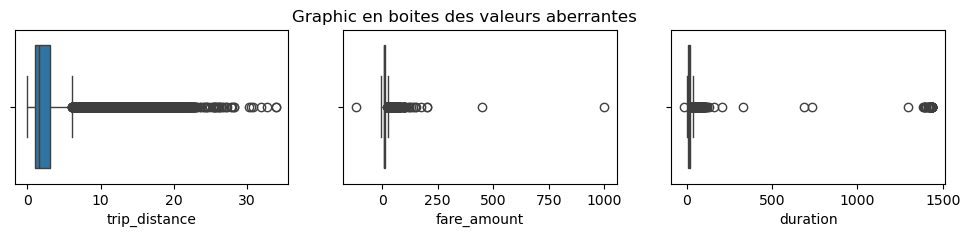

In [124]:
fig, axes = plt.subplots(1,3,figsize=(12,2))
fig.suptitle('Graphic en boites des valeurs aberrantes')
sns.boxplot(ax=axes[0], x=df['trip_distance'])
sns.boxplot(ax=axes[1], x=df['fare_amount'])
sns.boxplot(ax=axes[2], x=df['duration'])
plt.show()

**Observations**
1. Les trois variables contiennent des valeurs aberrantes. Certaines sont extrêmes, d'autres moins.

2. La distance à vol d'oiseau entre l'extrémité sud de Staten Island et l'extrémité nord de Manhattan est de 48 km (30 miles). Compte tenu de cette information et de la distribution des valeurs dans cette colonne, il est raisonnable de ne pas modifier ces valeurs. Cependant, les valeurs de `fare_amount` et `duration` présentent clairement des valeurs aberrantes problématiques, notamment dans les valeurs élevées.

3. Probablement pas pour les deux dernières, mais pour `trip_distance`, cela pourrait convenir.

### 2.e: **Phases d'imputations** ***(remplacement des valeurs aberrantes par des valeurs raisonables)***
* Les variables concernees sont: `trip_distance` et `duration`

****Valeurs aberrantes pour la variable `trip_distance`****

1. Les statistiques descriptives indiquent la présence de distances de trajet de 0. Ces valeurs reflètent-elles des données erronées ou s'agit-il de trajets très courts arrondis à l'inférieur ?
2. Pour le vérifier, triez les valeurs de la colonne, supprimez les doublons et examinez les 10 valeurs les plus faibles. S'agit-il de valeurs arrondies ou de valeurs exactes ?

In [125]:
# Tri de la colonne trip_distance, suppression des doublons et affichage des 10 1res colonnes
sorted(set(df['trip_distance']))[:10]

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

Noud avons des distances enregistrées avec une grande précision. Mais si un passager annulait une course il est possible que certaines distances soient nulles. Verifions s'il exite suffisamment de valeurs nulles dans les données qui sont susceptibles de poser problème.

Dans ce cas on calcule le nombre de trajets pour lesquels `trip_distance` est nul.

In [126]:
# Calcul du nombre total des enregistrements dont la valeur de 'trip_distance' est =0
sum(df['trip_distance']==0)

148

**Remarque :** 148 trajets sur environ 23 000 sont relativement insignifiants. On pouvait envisager d'imputer la valeur 0,01, mais cela n'aurait probablement qu'un impact négligeable sur le modèle. Par conséquent, la colonne `trip_distance` restera inchangée concernant les valeurs aberrantes.

****Valeurs aberrantes pour la variable `fare_amount`****

In [127]:
# Affichage des stats descriptives pour la colone 'fare_amount'
df['fare_amount'].describe()

count   22699.00
mean       13.03
std        13.24
min      -120.00
25%         6.50
50%         9.50
75%        14.50
max       999.99
Name: fare_amount, dtype: float64

**Remarque :** L'étendue des valeurs de la colonne `fare_amount` est importante et les valeurs extrêmes sont peu pertinentes.

* **Valeurs faibles :** Les valeurs négatives posent problème. Une valeur nulle pourrait être acceptable si le taxi avait enregistré une course immédiatement annulée.

* **Valeurs élevées :** Le montant maximal de la course dans cet ensemble de données est proche de 1 000 $, ce qui semble très improbable. Il est possible de plafonner les valeurs élevées de cette variable en se basant sur l'intuition et les statistiques. 

L'écart interquartile (EIQ) est de 8 dollars. La formule standard `Q3 + (1,5 * IQR)` donne 26,50 dollars. Cela ne semble pas approprié pour le plafond tarifaire maximal. Dans ce cas, nous utiliserons un facteur de `6`, ce qui donne un plafond de 62,50 $.

Imputer les valeurs inférieures à 0 $ par `0`.

***Valeur minimale pour `fare_amount`***

In [128]:
# Imputation des valeurs negatives (<0 $) par 0 dans la colonne 'fare_amount'
df.loc[df['fare_amount']<0, 'fare_amount']=0
df['fare_amount'].min()

np.float64(0.0)

***Valeur maximale pour `fare_amount`***

In [129]:
def val_aber(col_list, facteur_iqr):    
    '''
    Imputer les valeurs limites supérieures dans les colonnes spécifiées en fonction de leur intervalle interquartile.
    Arguments :
               column_list : Liste des colonnes à parcourir
               iqr_factor : Nombre représentant x dans la formule :
               Q3 + (x * IQR): Utilisé pour déterminer le seuil maximal, au-delà duquel une valeur est considérée comme aberrante.
    L’écart interquartile (IQR) est calculé pour chaque colonne de column_list et les valeurs dépassant le seuil supérieur 
     de chaque colonne sont imputées avec la valeur de ce seuil.

    '''
    for col in col_list:
        # Imputation des valeurs negatives a '0'
        df.loc[df[col]<0, col]=0
        # Calcul du seuil superieur: Notion des quantiles et d'ecart interquartile
        q1=df[col].quantile(0.25)
        q3=df[col].quantile(0.75)
        iqr=q3-q1
        seuil_sup=q3+(facteur_iqr*iqr)
        print(col)
        print('Q3:', q3)
        print(f'Seuil superieur: {seuil_sup:.2f}')

        # Reaffectation ou Imputation des valeurs aberrantes au seuil superieur
        df.loc[df[col]> seuil_sup, col]=seuil_sup
        print()
        print(df[col].describe())

In [130]:
val_aber(['fare_amount'], 6)

fare_amount
Q3: 14.5
Seuil superieur: 62.50

count   22699.00
mean       12.90
std        10.54
min         0.00
25%         6.50
50%         9.50
75%        14.50
max        62.50
Name: fare_amount, dtype: float64


****Valeurs aberrantes pour la variable `duration`****

In [131]:
df['duration'].describe()

count   22699.00
mean       17.01
std        62.00
min       -16.98
25%         6.65
50%        11.18
75%        18.38
max      1439.55
Name: duration, dtype: float64

Le La colonne `duration` présente aussi des valeurs problématiques à ses extrémités.

* **Valeurs basses :** Aucune valeur ne doit représenter une durée négative. Imputer toutes les durées négatives par `0`.

* **Valeurs hautes :** Imputer les valeurs hautes de la même manière que les valeurs aberrantes élevées pour les tarifs : `Q3 + (6 * IQR)`.

In [132]:
# Imputation des valeurs extremes negatives 
df.loc[df['duration']<0, 'duration']=0
df['duration'].min()

np.float64(0.0)

In [133]:
# imputation des valeurs extremes depassant le seuil superieur
val_aber(['duration'],6)

duration
Q3: 18.38
Seuil superieur: 88.76

count   22699.00
mean       14.46
std        11.95
min         0.00
25%         6.65
50%        11.18
75%        18.38
max        88.76
Name: duration, dtype: float64


### 3. **Ingenierie des variables**

****Creation de la colonne `mean_distance`****

**NB:**  Une fois déployé, le modèle ne connaîtra la durée d'un trajet qu'après l'execution de ce dernier. Il est donc impossible d'entraîner un modèle utilisant cette caractéristique. Cependant, l'on peut utiliser des statistiques des trajets connus pour généraliser à ceux qui ne le sont pas.

Dans cette étape, l'on va créer une colonne nommée `mean_distance` qui va enregistrer la distance moyenne pour chaque groupe de trajets partageant les mêmes points de départ et d'arrivée.

Autrement dit tous les trajets partageant une même paire de points de départ et d'arrivée sont regroupés et leur distance moyenne est calculée.

Comme les positions de depart `PULocationID` et d'arret `DOLocationID` sont connues, l'on va commencer par créer une colonne auxiliaire appelée `pickup_dropoff`, qui contient la combinaison unique des identifiants des lieux de depart et d'arret pour chaque ligne.

Pour y parvenir l'on va convertir les identifiants des lieux de depart et d'arret en chaînes de caractères puis les concaténer en les séparant par un espace. Cet espace permet, par exemple, de faire encoder différemment un trajet avec les points de départ/arrivée 12 et 151 et un trajet avec les points 121 et 51.

In [134]:
# Creation de la colonne pickup_dropoff
df['pickup_dropoff']=df['PULocationID'].astype(str) + ' ' + df['DOLocationID'].astype(str)
df['pickup_dropoff'].head(5)

0    100 231
1     186 43
2    262 236
3     188 97
4      4 112
Name: pickup_dropoff, dtype: object

L'on va en suite utiliser l'instruction `groupby()` pour regrouper chaque ligne selon la nouvelle colonne `pickup_dropoff`, calculer la <U>moyenne</u> et ne conserver que les valeurs de la colonne `trip_distance`. Affectez les résultats à une variable nommée `grouped`.

In [135]:
grouped=df.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]
grouped[:5]

,trip_distance
pickup_dropoff,
1 1,2.43
10 148,15.70
100 1,16.89
100 100,0.25
100 107,1.18


Ce faisant, l'on obtient un dictionnaire dont la clé est `trip_distance` et dont les valeurs sont un autre dictionnaire. Les clés de ce dictionnaire interne correspondent aux paires de points de depart/arret et ses valeurs correspondent aux distances moyennes calculees. Ce sont ces informations que vous recherchez.

Ce n'est pas cette presentation que nous cherchons cependant; donc il faut modifier ou reassigner le dictionnaire `grouped_dict` afin qu'il ne contienne que le dictionnaire interne. Autrement dit, supprimez `trip_distance` comme clé.

In [142]:
grouped_dict=grouped.to_dict()
grouped_dict=grouped_dict['trip_distance']

1. Créer une colonne `mean_distance` qui est une copie de la colonne auxiliaire `pickup_dropoff`.

2. Utiliser la méthode `map()`sur la série `mean_distance`; Passer `grouped_dict` comme argument.

3. Réaffectez le résultat à la série `mean_distance`.

In [144]:
# Creer la colonne 'mean_distance' qui une copie de la colonne auxiliaire 'pickup_dropoff'
df['mean_distance']=df['pickup_dropoff']

# Mapper le dictionnaire 'group_dict' a la colonne 'mean_distance'
df['mean_distance']=df['mean_distance'].map(grouped_dict)


In [153]:
# Verification que le mappage a fonctionner
df[(df['PULocationID']==100) & (df['DOLocationID']==232)][['mean_distance']]
df[['mean_distance']][:5]

,mean_distance
0,3.52
1,3.11
2,0.88
3,3.70
4,4.44


L'on va utiliser le meme processus pour creer la colonne `mean_duration`.

In [154]:
grouped=df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration']]

In [157]:
#Créer un dictionnaire où les clés sont les points de depart/arret uniques et les valeurs sont
# la durée moyenne des trajets pour tous les trajets avec ces combinaisons de paires de points
grouped_dict=grouped.to_dict()
grouped_dict=grouped_dict['duration']

df['mean_duration']=df['pickup_dropoff']
df['mean_duration']=df['mean_duration'].map(grouped_dict)

In [160]:
# Verifaction que le mappage a fonctionne
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_duration']]
df[['mean_duration']].head(5)

,mean_duration
0,22.85
1,24.47
2,7.25
3,30.25
4,14.62


****Creation des colonnes `day` et `month`****

In [161]:
# Creation de la colonne 'day'
df['day']=df['tpep_pickup_datetime'].dt.day_name().str.lower()

# Creation de la colonne 'month'
df['month']=df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

****Créer la colonne `rush_hour` (heures de pointe)****

Définir les heures de pointe comme suit :

* Tout jour de la semaine (sauf samedi et dimanche) ET

* Soit de 6h00 à 10h00, soit de 16h00 à 20h00

Créer une colonne binaire `rush_hour` contenant 1 si la course a eu lieu pendant les heures de pointe et 0 sinon.

In [174]:
#  Creer la colonne 'heures de pointe'
df['rush_hour']=df['tpep_pickup_datetime'].dt.hour

In [175]:
# Application de la fonction 'heure_pointe a la nouvelle colonne 
df['rush_hour'] = 0

mask = (~df.day.isin(['saturday','sunday'])) & (
        ((df.rush_hour <6) & (df.rush_hour < 10)) |
        ((df.rush_hour <=16) & (df.rush_hour < 20))
)

df.loc[mask, 'rush_hour'] = 1
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.00,0.30,16.56,14.07,100 231,3.52,22.85,saturday,mar,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.00,0.30,20.80,26.50,186 43,3.11,24.47,tuesday,apr,1
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.00,0.30,8.75,7.20,262 236,0.88,7.25,friday,dec,1
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.00,0.30,27.69,30.25,188 97,3.70,30.25,sunday,may,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.00,0.30,17.80,16.72,4 112,4.44,14.62,saturday,apr,0


## **4. Creation d'un Graphic en nuage de points**

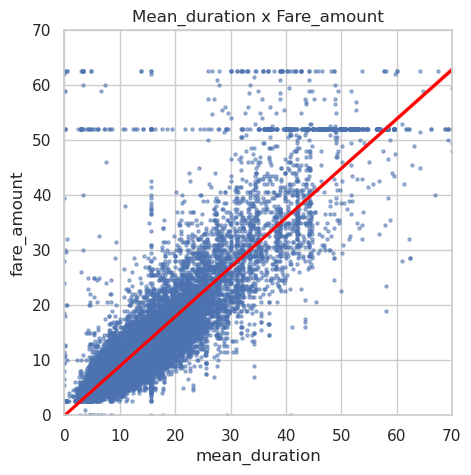

In [177]:
# Creer un graphic en nuage de points pour visualiser la relation entre 'mean_duration' et 'fare_amount'
sns.set(style='whitegrid'); f = plt.figure(figsize=(5,5))
sns.regplot(data=df, x='mean_duration', y = 'fare_amount',
           scatter_kws={'alpha':0.5, 's':5},
           line_kws={'color': 'red'})
plt.xlim(0,70)
plt.ylim(0,70)
plt.title('Mean_duration x Fare_amount')
plt.show()


**Constats :** La variable `mean_duration` est bien corrélée à la variable cible (`fare_amount`). 

Mais que représentent les lignes horizontales autour des prix de 52 et 63 dollars ? Quelles sont leurs valeurs et combien y en a-t-il ?

Vous savez ce que représente l'une des lignes. 62,50 dollars est le montant maximal imputé aux valeurs aberrantes ; toutes les anciennes valeurs aberrantes auront donc désormais un tarif de 62,50 $. Que représente alors l'autre ligne ?

Vérifiez la valeur des courses sur la deuxième ligne horizontale du nuage de points.

In [179]:
# Verification des valeurs autour de la ligne horizontale 2
df[df['fare_amount']>50]['fare_amount'].value_counts().head()

fare_amount
52.00    514
62.50     84
59.00      9
50.50      9
57.50      8
Name: count, dtype: int64

**Note :** Il y a 514 trajets dont le tarif était de 52 $.

***Examen des 30 premiers trajets***

In [180]:
# Examen des 30 premiers de ces trajets.
pd.set_option('display.max_columns', None)
df[df['fare_amount']==52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,18.90,2,N,236,132,1,52.00,0.00,0.50,14.58,5.54,0.30,72.92,36.80,236 132,19.21,40.50,sunday,mar,0
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,18.00,2,N,132,163,1,52.00,0.00,0.50,0.00,0.00,0.30,52.80,66.85,132 163,19.23,52.94,saturday,jun,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.00,0.00,0.50,0.00,0.00,0.30,52.80,0.97,132 132,2.26,3.02,saturday,nov,0
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,18.93,2,N,132,79,2,52.00,0.00,0.50,0.00,0.00,0.30,52.80,29.18,132 79,19.43,47.27,wednesday,dec,1
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,17.99,2,N,132,234,1,52.00,0.00,0.50,14.64,5.76,0.30,73.20,29.48,132 234,17.65,49.83,sunday,sep,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,18.40,2,N,132,48,2,52.00,4.50,0.50,0.00,5.54,0.30,62.84,39.83,132 48,18.76,58.24,tuesday,feb,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.00,0.00,0.50,0.00,5.76,0.30,58.56,15.62,228 88,4.73,15.62,monday,jun,1
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,18.21,2,N,132,48,2,52.00,0.00,0.50,0.00,5.76,0.30,58.56,45.45,132 48,18.76,58.24,thursday,aug,1
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,17.27,2,N,186,132,2,52.00,0.00,0.50,0.00,5.76,0.30,58.56,42.85,186 132,17.10,42.92,tuesday,sep,1
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,18.34,2,N,132,148,1,52.00,0.00,0.50,5.00,0.00,0.30,57.80,71.58,132 148,17.99,46.34,sunday,apr,0


**Remarque:** Il semble que presque tous les trajets des 30 premières lignes où le prix du billet est de 52 dollars commencent ou se terminent à l'emplacement 132, et tous ont un `RatecodeID` égal à 2.

Il n'y a pas de raison apparente expliquant pourquoi l'emplacement 132 présente autant de tarifs de 52 dollars. Ces tarifs semblent apparaître à différents jours, à différentes heures, avec les deux opérateurs et durant tous les mois. Cependant, on observe de nombreux péages de 5,76 dollars et 5,54 dollars. Cela semble indiquer que l'emplacement 132 se situe dans une zone où les péages sont fréquents. Il s'agit probablement d'un aéroport.

Le dictionnaire de données indique que `RatecodeID` égal à 2 correspond aux courses pour l'aéroport JFK (aéroport international John F. Kennedy). Une recherche rapide sur Google avec les mots-clés « taxi new york city flat rate $52 » confirme qu'en 2017 (année de collecte de ces données), un tarif forfaitaire était effectivement appliqué pour les courses en taxi entre l'aéroport JFK (dans le Queens) et Manhattan.

Comme `RatecodeID` est présent dans le dictionnaire de données, les valeurs de ce code tarifaire peuvent être réinjectées dans les données après l'exécution du modèle. Ainsi, ces données seront toujours exactes.

### **5. Isolation des variables du modele**

****Suppression les variables redondantes, non pertinentes ou indisponibles en environnement déployé.****

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

In [204]:
df2=df.copy()
df2=df2.drop(['Unnamed: 0','tpep_pickup_datetime', 'tpep_dropoff_datetime', 
              'trip_distance','RatecodeID', 'store_and_fwd_flag', 
              'PULocationID', 'DOLocationID','payment_type','extra','mta_tax','tip_amount',
              'tolls_amount','improvement_surcharge','total_amount','duration', 'pickup_dropoff',
              'day','month'], axis=1
            )
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


### **6. Creation des paires de graphics**
Creer des paires de graphics pour visuliser les relations entre les variables `fare_amount`, `mean_distance` et `mean_duration`

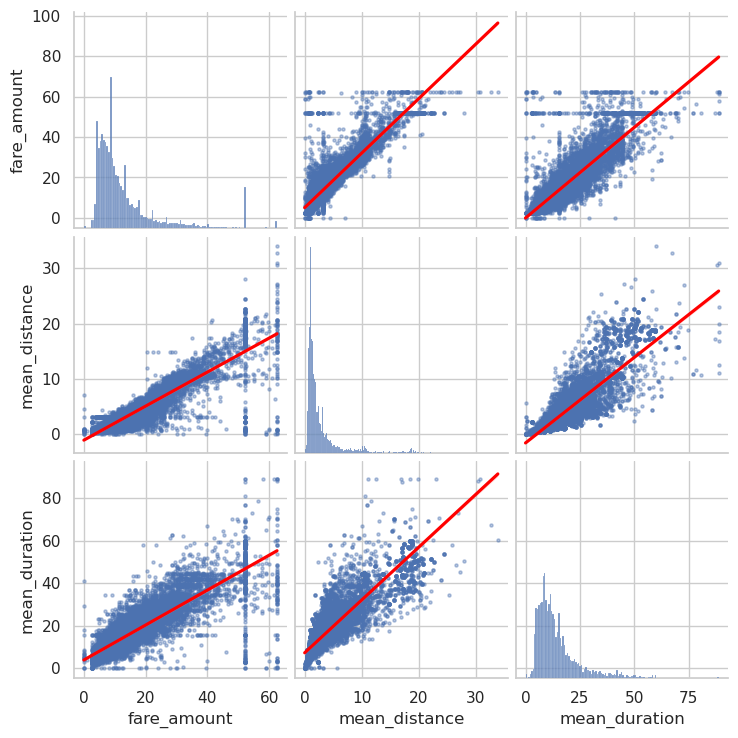

In [193]:
# Creation des paires plots pour la visualisation des reltions
sns.pairplot(
    df2,
    vars=['fare_amount', 'mean_distance', 'mean_duration'],
    kind='reg',
    plot_kws={
        'scatter_kws':{'alpha':0.4, 's':5},
        'line_kws':{'color':'red'}
    }
)

**NB:** Ces variables présentent toutes une corrélation linéaire. Approfondissez cette observation.

### **7: Identification des correlations**

Ensuite, créez une matrice de corrélation pour identifier les variables les plus corrélées.

In [194]:
# Creer une matrice de correlation pour voir les variables les plus correlees, utilisant 'le coeff de correlation de Pearson'
df2.corr(method='pearson')


,VendorID,passenger_count,fare_amount,mean_distance,mean_duration,rush_hour
VendorID,1.00,0.27,0.00,0.00,0.00,0.00
passenger_count,0.27,1.00,0.01,0.01,0.02,-0.03
fare_amount,0.00,0.01,1.00,0.91,0.86,0.01
mean_distance,0.00,0.01,0.91,1.00,0.87,-0.01
mean_duration,0.00,0.02,0.86,0.87,1.00,0.01
rush_hour,0.00,-0.03,0.01,-0.01,0.01,1.00


*****Visualisation par une carte thermique de corrélation des données.*****

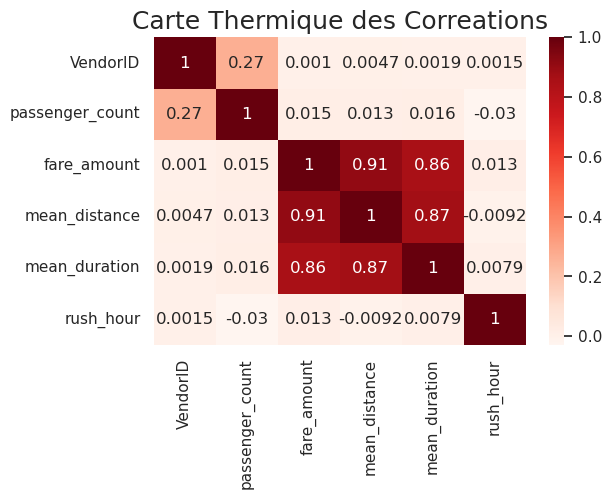

In [196]:
# Carte thermique des correlations
plt.figure(figsize=(6,4))
sns.heatmap(
    df2.corr(method='pearson'),
    annot=True,
    cmap='Reds'
)
plt.title('Carte Thermique des Correations', fontsize=18)
plt.show()

**Remarque :** `mean_duration` et `mean_distance` sont toutes deux fortement corrélées avec la variable cible `fare_amount`. Elles sont également corrélées entre elles, avec un coefficient de corrélation de Pearson de 0,87.

Rappelons que des variables explicatives fortement corrélées peuvent être problématiques pour les modèles de régression linéaire lorsqu'on souhaite tirer des conclusions statistiques des données à partir du modèle. Cependant, des variables explicatives corrélées peuvent néanmoins servir à créer un prédicteur précis si la prédiction elle-même est plus importante que l'utilisation du modèle comme outil d'apprentissage des données.

Ce modèle prédira `fare_amount`, qui servira de variable prédictive dans les modèles d'apprentissage automatique. Il est donc conseillé d'essayer de modéliser avec les deux variables, même si elles sont corrélées.

Après l'analyse et la dérivation des variables étroitement liées, il est temps de commencer la construction du modèle.

### **8.a: Séparation des données en variable de résultat et variables explicatives**

In [197]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


* Définir vos variables X et y. X représente les variables explicatives et y représente la variable de résultat (cible).

In [212]:
# Supprimer la colonne cible des variables explicatives
X = df2.drop(columns=['fare_amount'])

# Définir la variable y
y = df2[['fare_amount']]

# Afficher les premières lignes
X.head()

,VendorID,passenger_count,mean_distance,mean_duration,rush_hour
0,2,6,3.52,22.85,0
1,1,1,3.11,24.47,1
2,1,1,0.88,7.25,1
3,2,1,3.70,30.25,0
4,2,1,4.44,14.62,0


### 8.b: Prétraitement des données

Encodage des variables catégorielles avec des variables factices

In [213]:
# Convertir VendorID en chaîne de caractères
X['VendorID'] = X['VendorID'].astype(str)

# Récupérer les variables factices
X = pd.get_dummies(X, drop_first=True).astype(int)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,6,3,22,0,1
1,1,3,24,1,0
2,1,0,7,1,0
3,1,3,30,0,1
4,1,4,14,0,1


### Diviser les données en ensembles d'entraînement et de test

Créer les ensembles d'entraînement et de test. L'ensemble de test doit contenir 20 % du total des échantillons.

Initialiser par `random_state=0`

In [214]:
# Créer les ensembles d'entraînement et de test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Standardiser les données

Utiliser `StandardScaler()`, `fit()` et `transform()` pour standardiser les variables `X_train`. 

Affecter les résultats à une variable appelée `X_train_scaled`.

In [215]:
# Standardiser les variables X
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

print("X_train mis à l'échelle :", X_train_scaled)

X_train mis à l'échelle : [[-0.50301524  1.00023227  0.20329053 -1.60062022  0.89286563]
 [-0.50301524 -0.66749501 -0.68798222  0.62475782  0.89286563]
 [ 0.27331093 -0.38954046 -0.58895191 -1.60062022 -1.11998936]
 ...
 [-0.50301524 -0.38954046 -0.68798222  0.62475782 -1.11998936]
 [-0.50301524 -0.66749501 -0.88604282  0.62475782 -1.11998936]
 [ 1.82596329  0.72227772  1.09456327  0.62475782  0.89286563]]


### Ajustement du modèle

Instanciation du modèle de regression lineaire (lr) et ajustement aux données d'entraînement.

In [259]:
# Ajustement du modèle aux données d'entraînement
lr=LinearRegression()

lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 8.c: Évaluation du modèle

### Données d'entraînement

Évaluer les performances de votre modèle en calculant la somme des carrés des résidus et le coefficient de détermination (R²). 

Calculez l'erreur absolue moyenne (MAE), l'erreur quadratique moyenne (MSE) et la racine carrée de la MSE.

In [258]:
r_sq=lr.score(X_train_scaled, y_train)
print(f'Coefficient de detrmination: {r_sq:.2f}')
y_pred_train=lr.predict(X_train_scaled)
print(f"R^2:{r2_score(y_train, y_pred_train):.2f}")
print(f"MAE:{mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"MSE:{mean_squared_error(y_train, y_pred_train):.2f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")

Coefficient de detrmination: 0.84
R^2:0.84
MAE:2.24
MSE:18.12
RMSE:4.26


### Données de test

Calcul des mêmes métriques sur les données de test. 

Ne pas oublier de normaliser les données `X_test` à l'aide du scaler ajusté aux données d'entraînement.

Ne pas réajuster le scaler aux données de test, transformer-les simplement. Nommer les résultats `X_test_scaled`.

In [229]:
# Mise a l'echelle de X_test
X_test_scaled=scaler.transform(X_test)

In [231]:
# Evaluation des performances du modele sur les donnees de test
r_sq_test=lr.score(X_test_scaled, y_test)
print(f'Coefficient de determination: {r_sq_test:.2f}')
y_pred_test=lr.predict(X_test_scaled)
print(f'R^2: {r2_score(y_test, y_pred_test):.2f}')
print(f'MAE:{mean_absolute_error(y_test, y_pred_test):.2f}')
print(f'MSE:{mean_squared_error(y_test, y_pred_test):.2f}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}')

Coefficient de determination: 0.87
R^2: 0.87
MAE:2.19
MSE:14.60
RMSE:3.82


**Remarque :** Les performances du modèle sont élevées sur les ensembles d'entraînement et de test, ce qui suggère un faible biais et l'absence de surapprentissage.

En effet, les scores de test sont même meilleurs que les scores d'entraînement.

Pour les données de test, un R² de 0,87 signifie que 87 % de la variance de la variable `fare_amount` est expliquée par le modèle.

L'erreur absolue moyenne est informative ici car, pour les besoins du modèle, une erreur de deux n'est pas 2 fois plus grave qu'une erreur de un.

### 9.a : Résultats

Calcul des valeurs `actual`, `predicted` et `residual` pour l'ensemble de test;

L'on va stocker ces valeurs comme colonnes dans un dataframe `results`.

In [233]:
# Créer un dataframe `results`
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
'predicted': y_pred_test.ravel()})

results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
5818,14.00,11.49,2.51
18134,28.00,16.44,11.56
4655,5.50,6.27,-0.77
7378,15.50,16.37,-0.87
13914,9.50,9.77,-0.27


### 9.b : Visualiser les résultats du modèle

Créer un nuage de points pour visualiser `actual` par rapport à `predicted`.

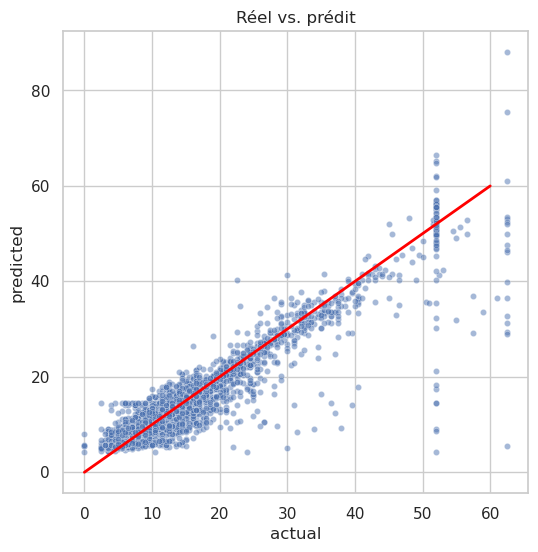

In [239]:
# Créer un nuage de points pour visualiser `predicted` par rapport à `actual`
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
y='predicted',
data=results,
s=20,
alpha=0.5,
ax=ax
)

# Tracer une ligne x=y pour montrer les résultats que donnerait le modèle étaient parfaits
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Réel vs. prédit');

* Visualiser la distribution des `résidus` à l'aide d'un histogramme

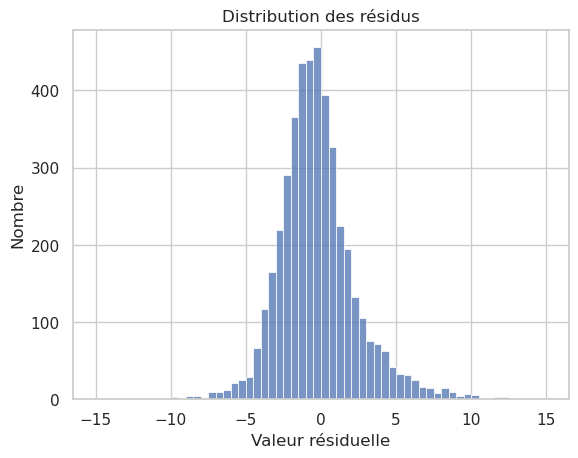

In [240]:
# Visualiser la distribution des `résidus`
sns.histplot(results['residual'], bins=np.arange(-15,15.5,0.5))
plt.title('Distribution des résidus')
plt.xlabel('Valeur résiduelle')
plt.ylabel('Nombre');

In [245]:
results['residual'].mean().round(3)

np.float64(-0.015)

**Remarque :** La distribution des résidus est approximativement normale et La moyenne est de -0,015. Les résidus représentent la variance de la variable dépendante non expliquée par le modèle. Une distribution normale autour de zéro est souhaitable, car elle indique que les erreurs du modèle sont uniformément réparties et non biaisées.

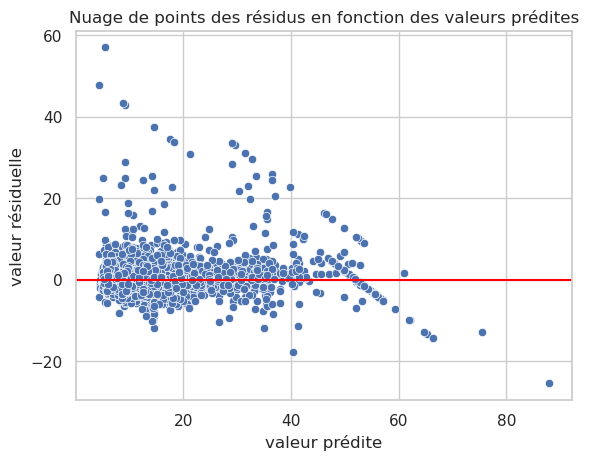

In [246]:
# Créer un nuage de points des `résidus` en fonction des `prédits`

sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Nuage de points des résidus en fonction des valeurs prédites')
plt.xlabel('valeur prédite')
plt.ylabel('valeur résiduelle')
plt.show()

**Remarque :** Les résidus du modèle sont uniformément répartis autour de zéro, à l'exception des lignes obliques allant du coin supérieur gauche au coin inférieur droit. Ces lignes correspondent au maximum imputé de 62,50 $ et au tarif forfaitaire de 52 $ pour les trajets depuis l'aéroport JFK.

### 9.c : Coefficients
L'on va se servir de l'attribut `coef_` de l'objet modele pour obtenir les coefficients du modèle. Les coefficients sont affichés dans l'ordre des variables utilisées pour entraîner le modèle.

In [268]:
# Obtenir les coefficients du modèle
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_.ravel()
})
coefficients

,feature,coefficient
0,passenger_count,0.03
1,mean_distance,7.02
2,mean_duration,2.92
3,rush_hour,0.18
4,VendorID_2,-0.05


In [269]:
print(lr.coef_.shape)
print(lr.coef_)

(1, 5)
[[ 0.03226327  7.01706896  2.9222433   0.17710692 -0.04836742]]


Les coefficients révèlent que la variable `mean_distance` est celle qui a le plus d'influence sur la prédiction finale du modèle. 

***Mais attention !*** Une interprétation erronée fréquente consiste à croire que pour chaque mile parcouru, le prix de la course augmente en moyenne de 7,02 dollars. C'est incorrect. Rappelons que les données utilisées pour entraîner le modèle ont été standardisées avec `StandardScaler()`. Par conséquent, les unités ne sont plus des miles. Autrement dit, on ne peut pas dire « pour chaque mile parcouru… », comme indiqué précédemment. 

***L'interprétation correcte de ce coefficient est la suivante :*** toutes choses égales par ailleurs, *pour chaque augmentation d'une unité de l'écart type*, le prix de la course augmente en moyenne de 7,02 $.

Notez également que, du fait de la présence de certaines variables fortement corrélées non supprimées, l'intervalle de confiance de cette évaluation est plus large.

Il faut donc reconvertir ces résultats en miles plutôt qu'en écart type (c'est-à-dire, rétablir l'échelle des données).

1. L'on va alors calculer l'écart type de `mean_distance` dans les données `X_train`.

2. Puis diviser le coefficient (7,02) par le résultat pour obtenir une interprétation plus intuitive.

In [271]:
# 1. Calcul de l'écart type de `mean_distance` dans les données X_train
print(X_train['mean_distance'].std())

# 2. Division du coefficient du modèle par l'écart type
print(7.02 / X_train['mean_distance'].std())

3.5978096163684694
1.951187180128168


L'on peut a present interpréter les résultats de manière plus intuitive : ***pour chaque tranche de 3,59 miles parcourus, le prix de la course a augmenté en moyenne de 7,02 dollars.*** 

Ou, plus precisement : **pour chaque mile parcouru, le tarif a augmenté en moyenne de 2.00 $**

### 9.d : Conclusion

**Quels sont les principaux enseignements tirés ?**

* La régression linéaire multiple est un outil puissant pour estimer une variable dépendante continue à partir de plusieurs variables indépendantes.

* L’analyse exploratoire des données est utile pour sélectionner les variables numériques et catégorielles pertinetes en vue d’une régression linéaire   multiple.

* L’ajustement de modèles de régression linéaire multiple peut nécessiter des essais et des erreurs pour sélectionner les variables qui correspondent    à un modèle précis tout en respectant les hypothèses du modèle (ou non, selon votre cas d’utilisation).

**Quels résultats peuvent être présentés ?**

* Vous pouvez discuter du respect des hypothèses de la régression linéaire et présenter les scores MAE et RMSE obtenus à partir du modèle.

# PERSPECTIVES

1. Obtenir les prédictions du modèle sur l’ensemble des données.

2. Imputer un tarif fixe de 52 $ pour tous les trajets dont le code tarifaire est « 2 ».

3. Vérifier les performances du modèle sur l’ensemble des données.

4. Enregistrer les prédictions finales ainsi que les colonnes `mean_duration` et `mean_distance` pour une utilisation ultérieure.

### 1. Prédiction sur l'ensemble des données

In [272]:
X_scaled = scaler.transform(X)

y_preds_full = lr.predict(X_scaled)

### 2. Imputation du tarif 2

Le dictionnaire de données indique que la colonne `RatecodeID` contient les informations suivantes :

1 = tarif standard
2 = JFK (aéroport)
3 = Newark (aéroport)
4 = Nassau ou Westchester
5 = tarif négocié
6 = trajet de groupe

Cela signifie que certains tarifs n'ont pas besoin d'être prédits. Ils peuvent simplement être imputés en fonction de leur code tarifaire. Plus précisément, tous les tarifs `2` peuvent être imputés à 52 $, car il s'agit d'un tarif forfaitaire pour l'aéroport JFK.

Les autres codes tarifaires présentent des variations (non affichées ici, mais vous pouvez les vérifier vous-même). Ce ne sont pas des tarifs fixes, ils resteront donc inchangés.

****Imputer la valeur `52` à toutes les prédictions où `RatecodeID` vaut `2`.****

In [273]:
# Créer un nouveau DataFrame contenant uniquement la colonne `RatecodeID` de l'ensemble de données.
final_preds = df[['RatecodeID']].copy()

# Ajouter une colonne contenant toutes les prédictions.
final_preds['y_preds_full'] = y_preds_full

# Imputer la valeur 52 à toutes les lignes où `RatecodeID` vaut `2`.
final_preds.loc[final_preds['RatecodeID']==2, 'y_preds_full'] = 52

# Vérifier le bon fonctionnement.
final_preds[final_preds['RatecodeID']==2].head()

,RatecodeID,y_preds_full
11,2,52.00
110,2,52.00
161,2,52.00
247,2,52.00
379,2,52.00


### 3. Vérification des performances du modele sur l'ensemble de données.

In [274]:
final_preds = final_preds['y_preds_full']
print('R^2:', r2_score(y, final_preds))
print('MAE:', mean_absolute_error(y, final_preds))
print('MSE:', mean_squared_error(y, final_preds))
print('RMSE:',np.sqrt(mean_squared_error(y, final_preds)))

R^2: 0.8881648066411436
MAE: 2.049824375952011
MSE: 12.426084381949954
RMSE: 3.525065159958033


### 4. Sauvegarde des prédictions finales avec les colonnes `mean_duration` et `mean_distance`

In [275]:
# Combinaison des colonnes de moyennes avec la colonne de prédictions
nyc_preds_means = df[['mean_duration', 'mean_distance']].copy()
nyc_preds_means['predicted_fare'] = final_preds

nyc_preds_means.head()

,mean_duration,mean_distance,predicted_fare
0,22.85,3.52,16.17
1,24.47,3.11,17.12
2,7.25,0.88,6.35
3,30.25,3.70,18.36
4,14.62,4.44,15.68


In [283]:
final_preds.to_csv('/drive/predictions.csv', index=False)

**Felicitations**